# Customer Segmentation — RFM Analysis & K-Means
**Oasis Infobyte Internship · Data Analytics · Level 1 — Task 2**<br>
**Author:** Ojewumi Asaph Felix

**Objective:** segment the customers of an e-commerce company according to their purchasing behaviour, in order to design **targeted marketing actions** for each group.

**Dataset:** *Online Retail* (UCI Machine Learning Repository) — 541,909 invoice lines of a UK-based online gift shop, from December 2010 to December 2011. Amounts are in pounds sterling (£).

> **Key results**
> - After cleaning, **4,334 customers** are described by 3 behavioural features: **Recency, Frequency, Monetary (RFM)**.
> - K-Means (K = 4, chosen with the Elbow Method) finds **4 clear segments**: Champions, Loyal Regulars, New & Promising, and Lost / Hibernating customers.
> - **Champions are only 16 % of customers but generate 64 % of revenue.**
> - **38 % of customers are "lost"**: they bought once, about 6 months ago.

**Contents**
1. Data loading and inspection
2. Data cleaning
3. Descriptive statistics (purchase value, frequency, customer lifetime value)
4. Feature selection: RFM
5. Standardisation
6. Choosing K: the Elbow Method
7. K-Means clustering and cluster visualisation
8. Cluster profiles
9. Marketing recommendations per segment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

BLUE, ORANGE, AQUA, YELLOW, GREY, INK, MUTED = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#b9b8b3", "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#cfcecb", "axes.labelcolor": MUTED, "axes.titleweight": "bold",
    "axes.titlesize": 12.5, "axes.titlecolor": INK, "axes.titlelocation": "left", "axes.titlepad": 12,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": "#ecebe8", "grid.linewidth": 0.8, "axes.axisbelow": True,
})

## 1. Data Loading and Inspection
The original UCI file is an Excel workbook (23 MB, ~90 s to read). It was converted once to a compressed CSV (`online_retail.csv.gz`) with the same content, so the notebook loads in a few seconds.

In [2]:
df = pd.read_csv("data/online_retail.csv.gz", dtype={"InvoiceNo": str, "StockCode": str},
                 parse_dates=["InvoiceDate"])
print("Shape:", df.shape)
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


In [4]:
issues = pd.Series({
    "Missing CustomerID": df["CustomerID"].isna().sum(),
    "Missing Description": df["Description"].isna().sum(),
    "Duplicated rows": df.duplicated().sum(),
    "Cancelled invoices (InvoiceNo starts with 'C')": df["InvoiceNo"].str.startswith("C").sum(),
    "Quantity ≤ 0": (df["Quantity"] <= 0).sum(),
    "UnitPrice ≤ 0": (df["UnitPrice"] <= 0).sum(),
}, name="rows")
issues.to_frame().assign(**{"% of rows": lambda t: (t["rows"] / len(df) * 100).round(1)})

,rows,% of rows
Missing CustomerID,135080,24.90
Missing Description,1454,0.30
Duplicated rows,5268,1.00
Cancelled invoices (InvoiceNo starts with 'C'),9288,1.70
Quantity ≤ 0,10624,2.00
UnitPrice ≤ 0,2517,0.50


In [5]:
# Stock codes that are not products (postage, fees, manual adjustments...)
codes = df.loc[~df["StockCode"].str.match(r"^\d{5}"), ["StockCode", "Description"]]
codes.drop_duplicates("StockCode").head(12)

,StockCode,Description
45,POST,POSTAGE
141,D,Discount
1423,C2,CARRIAGE
1814,DOT,DOTCOM POSTAGE
2239,M,Manual
4406,BANK CHARGES,Bank Charges
14436,S,SAMPLES
14514,AMAZONFEE,AMAZON FEE
21326,DCGS0076,SUNJAR LED NIGHT NIGHT LIGHT
24906,DCGS0003,BOXED GLASS ASHTRAY


**Observations:**
- **25 % of the lines have no `CustomerID`**. They cannot be linked to a customer, so they are useless for segmentation.
- **Cancelled invoices** (prefix `C`) have negative quantities: they are returns, not purchases.
- Some lines have a **price of 0** or are **not products** (`POST` = postage, `M` = manual, `BANK CHARGES`, `AMAZONFEE`…). Keeping them would distort how much customers really spend on products.

## 2. Data Cleaning
Each step is applied in order, and we record how many rows remain.

In [6]:
NON_PRODUCT = ["POST", "D", "M", "DOT", "BANK CHARGES", "AMAZONFEE", "C2", "CRUK", "PADS", "S", "B"]

steps = [("Raw data", len(df))]
clean = df.dropna(subset=["CustomerID"]);                    steps.append(("Remove lines without CustomerID", len(clean)))
clean = clean[~clean["InvoiceNo"].str.startswith("C")];      steps.append(("Remove cancelled invoices", len(clean)))
clean = clean[(clean["Quantity"] > 0) & (clean["UnitPrice"] > 0)]; steps.append(("Keep Quantity > 0 and UnitPrice > 0", len(clean)))
clean = clean.drop_duplicates();                             steps.append(("Remove duplicated rows", len(clean)))
clean = clean[~clean["StockCode"].isin(NON_PRODUCT)];         steps.append(("Remove non-product codes (postage, fees...)", len(clean)))

clean = clean.copy()
clean["CustomerID"] = clean["CustomerID"].astype(int).astype(str)
clean["Amount"] = clean["Quantity"] * clean["UnitPrice"]

report = pd.DataFrame(steps, columns=["Step", "Rows remaining"])
report["Rows removed"] = (-report["Rows remaining"].diff()).fillna(0).astype(int)
report

,Step,Rows remaining,Rows removed
0,Raw data,541909,0
1,Remove lines without CustomerID,406829,135080
2,Remove cancelled invoices,397924,8905
3,Keep Quantity > 0 and UnitPrice > 0,397884,40
4,Remove duplicated rows,392692,5192
5,"Remove non-product codes (postage, fees...)",391150,1542


In [7]:
print(f"Customers : {clean['CustomerID'].nunique():,}")
print(f"Invoices  : {clean['InvoiceNo'].nunique():,}")
print(f"Revenue   : £{clean['Amount'].sum():,.0f}")
print(f"Period    : {clean['InvoiceDate'].min().date()} → {clean['InvoiceDate'].max().date()}")

Customers : 4,334
Invoices  : 18,402
Revenue   : £8,737,228
Period    : 2010-12-01 → 2011-12-09


**Result:** **391,150 clean lines** from **4,334 customers** and 18,402 invoices remain (72 % of the raw data). Most of the removed rows are the lines without a customer ID.

## 3. Descriptive Statistics
- **Average purchase value** = average amount of one invoice (order).
- **Purchase frequency** = number of orders per customer over the year.
- **Customer lifetime value (CLV)** = total amount spent by a customer. With one year of history, we use the **historical 12-month CLV** (= average purchase value × purchase frequency for each customer).

In [8]:
orders = clean.groupby(["CustomerID", "InvoiceNo"])["Amount"].sum()
customers = clean.groupby("CustomerID").agg(orders=("InvoiceNo", "nunique"), clv=("Amount", "sum"))

stats = pd.DataFrame({
    "Average purchase value (£ per order)": orders.describe()[["mean", "50%", "std"]].values,
    "Purchase frequency (orders per customer)": customers["orders"].describe()[["mean", "50%", "std"]].values,
    "Customer lifetime value (£, 12 months)": customers["clv"].describe()[["mean", "50%", "std"]].values,
}, index=["mean", "median", "std"]).T
stats

,mean,median,std
Average purchase value (£ per order),474.80,301.65,"1,678.79"
Purchase frequency (orders per customer),4.25,2.00,7.63
"Customer lifetime value (£, 12 months)","2,015.97",662.57,"8,903.67"


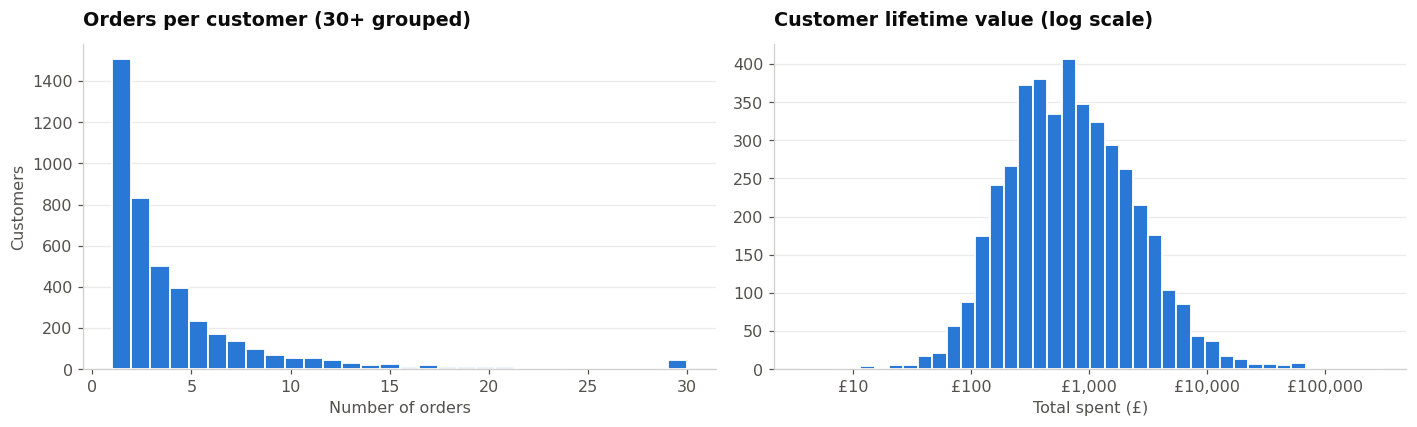

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(customers["orders"].clip(upper=30), bins=30, color=BLUE, edgecolor="white", linewidth=1.2)
axes[0].set_title("Orders per customer (30+ grouped)")
axes[0].set_xlabel("Number of orders")
axes[0].set_ylabel("Customers")
axes[0].grid(axis="x", visible=False)

axes[1].hist(np.log10(customers["clv"]), bins=40, color=BLUE, edgecolor="white", linewidth=1.2)
axes[1].set_title("Customer lifetime value (log scale)")
axes[1].set_xlabel("Total spent (£)")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"£{10 ** x:,.0f}"))
axes[1].grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig("images/descriptive.png")
plt.show()

**Observations:**
- An order is worth **£475 on average**, but the median is much lower: a few very large (wholesale) orders pull the mean up.
- **The median customer ordered only twice** in the year, and about a third ordered only once.
- CLV is extremely unequal: the mean (£2,016) is **3× the median (£663)**. A small group of customers brings most of the revenue — segmentation will show exactly who they are.

## 4. Feature Selection: RFM
We describe each customer with the 3 classic behavioural features used in marketing:

| Feature | Definition | A "good" customer has… |
|---|---|---|
| **Recency** | Days since the last purchase (reference date: the day after the last invoice) | a **low** recency |
| **Frequency** | Number of distinct orders | a **high** frequency |
| **Monetary** | Total amount spent (£) | a **high** monetary value |

In [10]:
ref_date = clean["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)
rfm = clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda d: (ref_date - d.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Amount", "sum"),
)
print("Reference date:", ref_date.date())
rfm.describe().T

Reference date: 2011-12-10


,count,mean,std,min,25%,50%,75%,max
Recency,"4,334.00",92.23,100.18,0.00,17.00,50.00,142.00,373.00
Frequency,"4,334.00",4.25,7.63,1.00,1.00,2.00,5.00,206.00
Monetary,"4,334.00","2,015.97","8,903.67",3.75,304.24,662.57,"1,631.62","279,138.02"


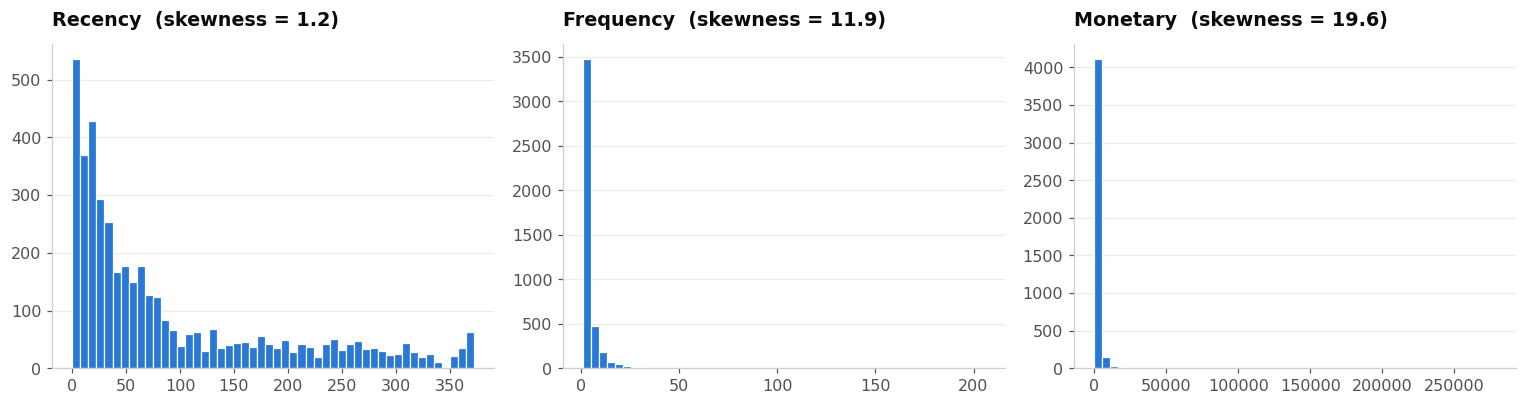

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, col in zip(axes, rfm.columns):
    ax.hist(rfm[col], bins=50, color=BLUE, edgecolor="white", linewidth=0.8)
    ax.set_title(f"{col}  (skewness = {rfm[col].skew():.1f})")
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig("images/rfm_distributions.png")
plt.show()

**Observation:** Frequency and Monetary are **extremely right-skewed** (skewness of 12 and 20). K-Means uses distances, so a few huge customers would dominate the result. We therefore apply a **log transformation** (`log(1 + x)`) before standardising, which brings the distributions much closer to symmetric.

## 5. Standardisation
Recency is in days (0–373), Frequency in orders (1–206) and Monetary in pounds (up to £279,000). Without scaling, Monetary would decide the clusters alone. `StandardScaler` gives every feature a mean of 0 and a standard deviation of 1.

In [12]:
rfm_log = np.log1p(rfm)
scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)

pd.DataFrame(X, columns=rfm.columns).describe().loc[["mean", "std", "min", "max"]].round(2)

,Recency,Frequency,Monetary
mean,0.00,0.00,0.00
std,1.00,1.00,1.00
min,-2.75,-0.95,-4.00
max,1.53,5.85,4.75


## 6. Choosing K: the Elbow Method
We run K-Means for K = 2 to 10 and plot the **inertia** (sum of squared distances to the cluster centres). The "elbow" is where adding a cluster stops bringing a large improvement. The **silhouette score** is shown as a second opinion.

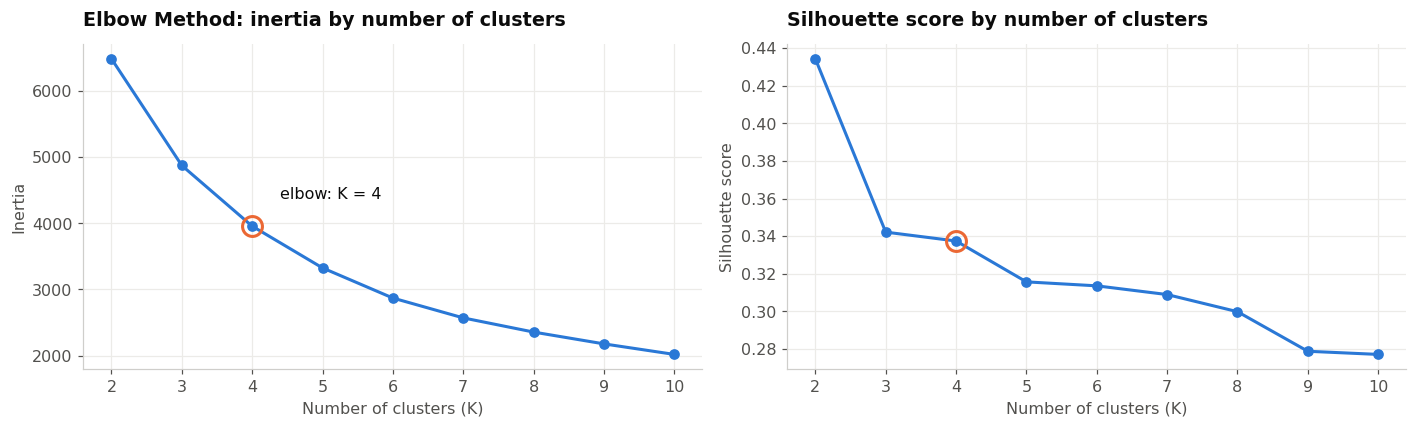

,2,3,4,5,6,7,8,9,10
inertia,"6,481.28","4,870.93","3,955.71","3,325.20","2,870.61","2,571.17","2,357.26","2,179.04","2,020.11"
silhouette,0.43,0.34,0.34,0.32,0.31,0.31,0.30,0.28,0.28


In [13]:
ks = range(2, 11)
inertia, silhouette = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ks, inertia, color=BLUE, lw=2, marker="o", ms=6)
axes[0].plot(4, inertia[2], marker="o", ms=13, mfc="none", mec=ORANGE, mew=2)
axes[0].annotate("elbow: K = 4", (4, inertia[2]), xytext=(18, 18), textcoords="offset points", color=INK)
axes[0].set_title("Elbow Method: inertia by number of clusters")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia")

axes[1].plot(ks, silhouette, color=BLUE, lw=2, marker="o", ms=6)
axes[1].plot(4, silhouette[2], marker="o", ms=13, mfc="none", mec=ORANGE, mew=2)
axes[1].set_title("Silhouette score by number of clusters")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.savefig("images/elbow.png")
plt.show()

pd.DataFrame({"inertia": inertia, "silhouette": silhouette}, index=list(ks)).round(3).T

**Choice: K = 4.**
- The inertia curve bends clearly between K = 3 and K = 5: after K = 4, each new cluster brings a much smaller gain.
- K = 2 has the best silhouette, but only splits customers into "good" and "bad", which is too coarse to act on.
- K = 4 keeps a silhouette almost equal to K = 3 (0.34) and adds a **useful business segment**: recent customers who have bought only a few times.

## 7. K-Means Clustering and Visualisation

In [14]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(X)

# Give each cluster a business name from its median R, F, M (independent of K-Means label order)
med = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].median()
names = {}
names[med["Monetary"].idxmax()] = "Champions"
names[med["Recency"].idxmax()] = "Lost / Hibernating"
rest = med.drop(index=list(names))
names[rest["Recency"].idxmin()] = "New & Promising"
names[rest["Recency"].idxmax()] = "Loyal Regulars"

ORDER = ["Champions", "Loyal Regulars", "New & Promising", "Lost / Hibernating"]
COLORS = {"Champions": BLUE, "Loyal Regulars": AQUA, "New & Promising": ORANGE, "Lost / Hibernating": GREY}
MARKERS = {"Champions": "o", "Loyal Regulars": "s", "New & Promising": "^", "Lost / Hibernating": "D"}
rfm["Segment"] = pd.Categorical(rfm["Cluster"].map(names), categories=ORDER)
rfm["Segment"].value_counts().reindex(ORDER)

Segment
Champions              686
Loyal Regulars        1182
New & Promising        820
Lost / Hibernating    1646
Name: count, dtype: int64

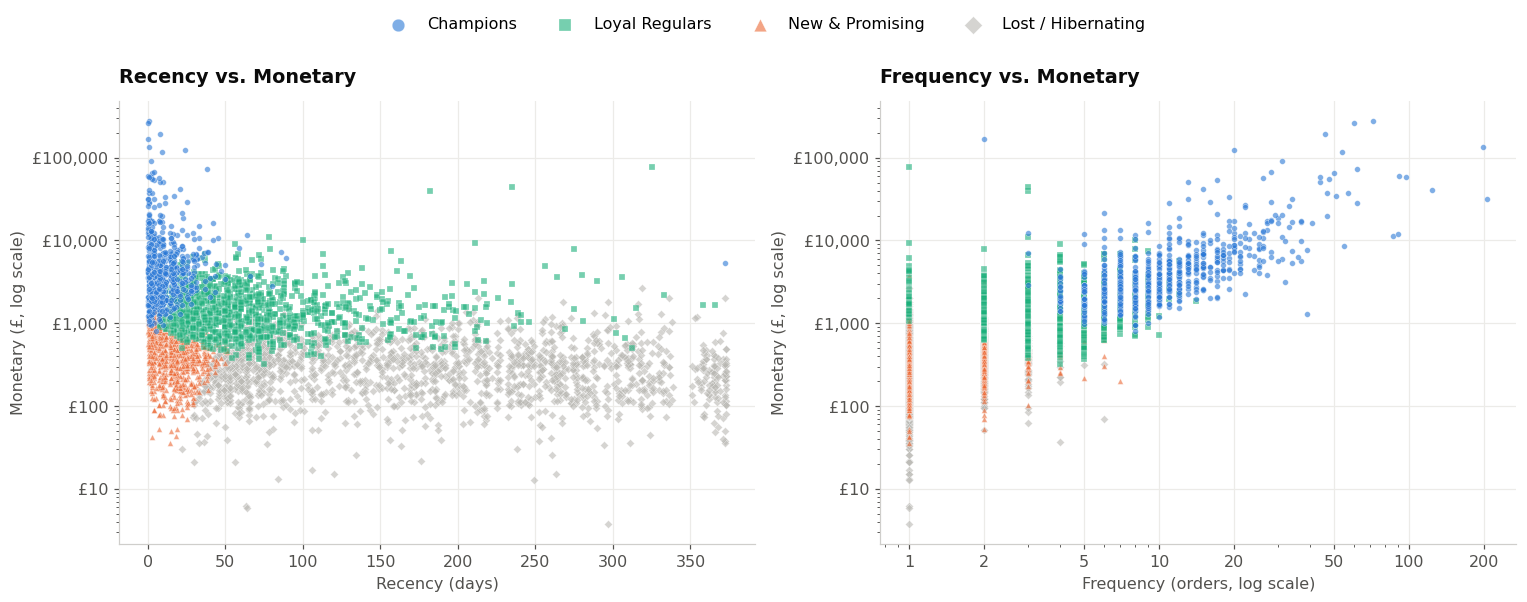

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
pairs = [("Recency", "Monetary"), ("Frequency", "Monetary")]
for ax, (xc, yc) in zip(axes, pairs):
    for seg in ORDER[::-1]:
        s = rfm[rfm["Segment"] == seg]
        ax.scatter(s[xc], s[yc], s=14, alpha=0.6, color=COLORS[seg], marker=MARKERS[seg],
                   edgecolors="white", linewidths=0.3, label=seg)
    ax.set_yscale("log")
    if xc == "Frequency":
        ax.set_xscale("log")
        ax.set_xticks([1, 2, 5, 10, 20, 50, 100, 200])
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
        ax.xaxis.set_minor_formatter(mtick.NullFormatter())
    ax.set_xlabel(xc + (" (days)" if xc == "Recency" else " (orders, log scale)"))
    ax.set_ylabel("Monetary (£, log scale)")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"£{v:,.0f}"))
    ax.set_title(f"{xc} vs. {yc}")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[::-1], labels[::-1], loc="upper center", ncol=4, frameon=False, markerscale=2.2, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.savefig("images/clusters_scatter.png")
plt.show()

**Observations:**
- **Recency vs. Monetary:** Champions (blue) sit on the **left and at the top** — they bought recently and spent a lot. Lost customers (grey) are on the **right and at the bottom**.
- **Frequency vs. Monetary:** spending grows with the number of orders. Champions order the most; Lost customers mostly ordered **only once**.
- The two middle groups differ mainly by **recency**: New & Promising customers bought recently but still little; Loyal Regulars buy regularly for medium amounts.

## 8. Cluster Profiles

In [16]:
profile = rfm.groupby("Segment", observed=True).agg(
    customers=("Recency", "size"),
    recency_median=("Recency", "median"),
    frequency_median=("Frequency", "median"),
    monetary_median=("Monetary", "median"),
    recency_mean=("Recency", "mean"),
    frequency_mean=("Frequency", "mean"),
    monetary_mean=("Monetary", "mean"),
    revenue=("Monetary", "sum"),
)
profile["% of customers"] = profile["customers"] / profile["customers"].sum() * 100
profile["% of revenue"] = profile["revenue"] / profile["revenue"].sum() * 100
profile.round(1)

,customers,recency_median,frequency_median,monetary_median,recency_mean,frequency_mean,monetary_mean,revenue,% of customers,% of revenue
Segment,,,,,,,,,,
Champions,686,8.00,10.00,"3,715.40",11.10,13.90,"8,153.80","5,593,496.40",15.80,64.00
Loyal Regulars,1182,52.00,4.00,"1,357.50",68.10,4.20,"1,801.40","2,129,199.80",27.30,24.40
New & Promising,820,17.00,2.00,467.30,17.40,2.10,541.00,"443,648.20",18.90,5.10
Lost / Hibernating,1646,173.00,1.00,296.70,180.60,1.30,346.80,"570,883.20",38.00,6.50


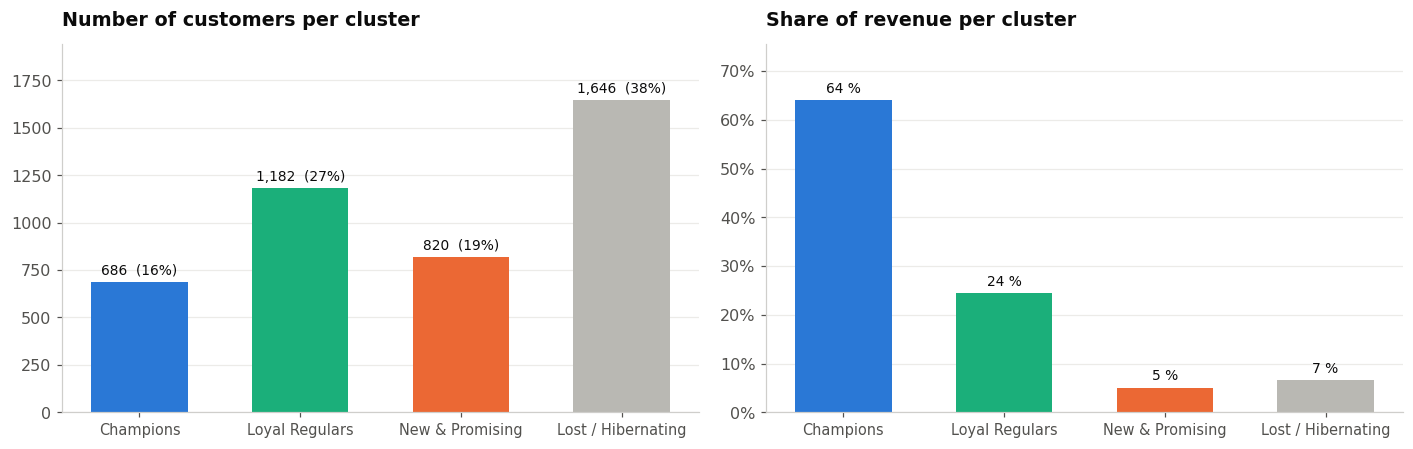

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

counts = profile["customers"]
b = axes[0].bar(counts.index.astype(str), counts.values, color=[COLORS[s] for s in counts.index], width=0.6)
axes[0].bar_label(b, labels=[f"{v:,}  ({v / counts.sum():.0%})" for v in counts.values], padding=3, color=INK, fontsize=9)
axes[0].set_title("Number of customers per cluster")
axes[0].set_ylim(0, counts.max() * 1.18)
axes[0].grid(axis="x", visible=False)

rev = profile["% of revenue"]
b = axes[1].bar(rev.index.astype(str), rev.values, color=[COLORS[s] for s in rev.index], width=0.6)
axes[1].bar_label(b, labels=[f"{v:.0f} %" for v in rev.values], padding=3, color=INK, fontsize=9)
axes[1].set_title("Share of revenue per cluster")
axes[1].set_ylim(0, rev.max() * 1.18)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(100))
axes[1].grid(axis="x", visible=False)

for ax in axes:
    ax.tick_params(axis="x", labelsize=9.5)
plt.tight_layout()
plt.savefig("images/cluster_sizes.png")
plt.show()

**Customer types**

| Segment | Profile (medians) | Who are they? |
|---|---|---|
| 🔵 **Champions** (16 %) | last purchase **8 days** ago, **10 orders**, **£3,700** | The best customers — probably retailers who reorder often. **16 % of customers, 64 % of revenue.** |
| 🟢 **Loyal Regulars** (27 %) | 52 days, 4 orders, £1,360 | Regular, medium-value customers. The pool from which future Champions can come. |
| 🟠 **New & Promising** (19 %) | 17 days, 2 orders, £470 | Recent customers with few orders so far. Their next purchases will decide whether they stay. |
| ⚪ **Lost / Hibernating** (38 %) | **173 days**, 1 order, £300 | Bought once, about 6 months ago, and never came back. Only 7 % of revenue. |

## 9. Marketing Recommendations per Segment

| Segment | Goal | Recommended actions |
|---|---|---|
| **Champions** | **Retain** — losing one of them costs as much as losing ~20 lost customers | VIP / loyalty programme, early access to new collections, a dedicated account manager, volume discounts. **Never** send them generic discount campaigns. |
| **Loyal Regulars** | **Upgrade** them to Champions | Personalised recommendations based on past orders, "spend £X more for free shipping", loyalty points that unlock a higher tier. |
| **New & Promising** | **Convert** the 2nd and 3rd purchase | Welcome series by e-mail, a discount on the next order within 30 days, best-seller suggestions. |
| **Lost / Hibernating** | **Win back** — cheaply | One automated win-back campaign ("We miss you" + one-time offer). If there is no response, stop spending marketing budget on them. |

**Conclusion**
- RFM + K-Means turned 400,000 invoice lines into **4 easy-to-understand customer groups**.
- The business depends heavily on a **small group of Champions (16 % → 64 % of revenue)**: keeping them is the top priority.
- The biggest group (38 %) is **lost customers**: improving the **second-purchase rate** of new customers is the best way to reduce this group in the future.

**Limitations**
- Only one year of data: the "lifetime" value is really a 12-month value.
- 25 % of the lines had no customer ID and were excluded, so part of the revenue is not attributed to any customer.
- K-Means creates round clusters of similar size; the borders between segments are not strict and should be reviewed with the marketing team.

In [18]:
rfm.drop(columns="Cluster").to_csv("data/rfm_segments.csv")
print("Saved data/rfm_segments.csv —", rfm.shape[0], "customers")

Saved data/rfm_segments.csv — 4334 customers
